<a href="https://colab.research.google.com/github/rochita-06/machine-learning-project/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving diabetes.csv to diabetes.csv
Dataset loaded successfully!
Shape: (2000, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0



========== LINEAR REGRESSION RESULTS ==========
Mean Absolute Error: 0.33440648461414724
Mean Squared Error: 0.16400144285266016
Root Mean Squared Error: 0.4049709160577586
R2 Score: 0.29444675172956825
Classification Accuracy: 0.775

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.91      0.84       253
           1       0.78      0.54      0.64       147

    accuracy                           0.78       400
   macro avg       0.78      0.73      0.74       400
weighted avg       0.78      0.78      0.76       400



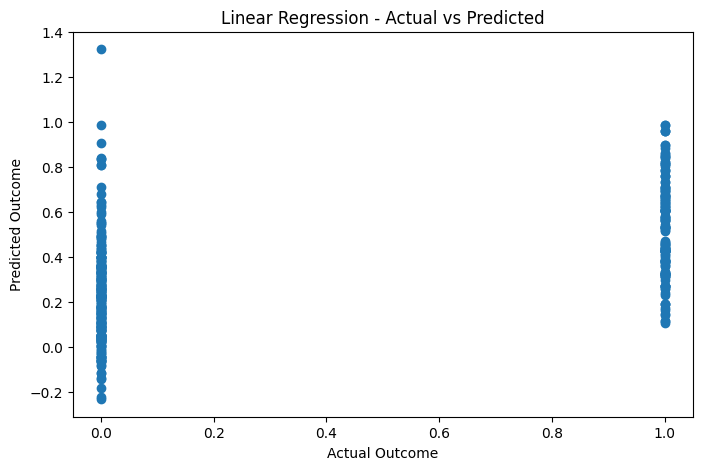

In [1]:
# ==========================================
# LINEAR REGRESSION - DIABETES DATASET
# ==========================================

# Upload dataset
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report

# Read uploaded file automatically
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

# Separate features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Replace invalid zero values
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[zero_columns] = X[zero_columns].replace(0, np.nan)

# Fill missing values with median
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Convert predictions to 0 and 1
y_pred_class = (y_pred >= 0.5).astype(int)

# Evaluation
print("\n========== LINEAR REGRESSION RESULTS ==========")

print("Mean Absolute Error:",
      mean_absolute_error(y_test, y_pred))

print("Mean Squared Error:",
      mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:",
      np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score:",
      r2_score(y_test, y_pred))

print("Classification Accuracy:",
      accuracy_score(y_test, y_pred_class))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

# Actual vs Predicted graph
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Outcome")
plt.ylabel("Predicted Outcome")
plt.title("Linear Regression - Actual vs Predicted")
plt.show()